In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
train = pd.read_csv('https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1989, 13)
Test shape: (498, 12)


,id,Date,Open,High,Low,Close,Volume,feature_ret_1d,feature_ret_5d,feature_sma_20_ratio,feature_vol_ratio_20d,feature_high_low_spread,target
0,0,2014-01-30,145.258090,146.054110,144.795091,145.582993,118938100,0.010601,-0.019476,-0.016530,1.018317,0.008648,0.021090
1,1,2014-01-31,143.779734,145.631706,143.706633,144.730087,194677900,-0.005859,-0.003969,-0.021019,1.614905,0.013301,0.032776
2,2,2014-02-03,144.559525,144.884428,141.196732,141.472900,254837100,-0.022505,-0.021572,-0.040753,1.972072,0.026066,0.057817
3,3,2014-02-04,142.106482,142.829401,141.424179,142.463882,165012400,0.007005,-0.020551,-0.032176,1.249410,0.009864,0.043503
4,4,2014-02-05,141.968372,142.601941,141.099250,142.285156,164230500,-0.001255,-0.012292,-0.031169,1.207785,0.010561,0.050979


Missing values:
id                         0
Date                       0
Open                       0
High                       0
Low                        0
Close                      0
Volume                     0
feature_ret_1d             0
feature_ret_5d             0
feature_sma_20_ratio       0
feature_vol_ratio_20d      0
feature_high_low_spread    0
target                     0
dtype: int64


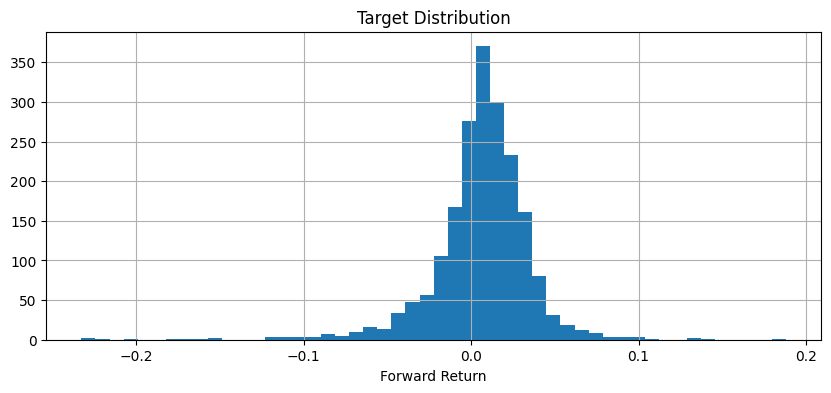


Target stats:
count    1989.000000
mean        0.006150
std         0.029940
min        -0.232884
25%        -0.004963
50%         0.008224
75%         0.021779
max         0.187979
Name: target, dtype: float64


In [ ]:
# Check for missing values
print("Missing values:")
print(train.isnull().sum())

# Target distribution
train['target'].hist(bins=50, figsize=(10,4))
plt.title('Target Distribution')
plt.xlabel('Forward Return')
plt.show()

# Basic stats
print("\nTarget stats:")
print(train['target'].describe())

In [ ]:
feature_cols = ['feature_ret_1d', 'feature_ret_5d', 'feature_sma_20_ratio',
                'feature_vol_ratio_20d', 'feature_high_low_spread']

X_train = train[feature_cols]
y_train = train['target']
X_test = test[feature_cols]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1989, 5)
X_test shape: (498, 5)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

lr_scores = []
for train_idx, val_idx in tscv.split(X_train):
    model_lr = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', LinearRegression())
    ])
    model_lr.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    val_pred = model_lr.predict(X_train.iloc[val_idx])
    score = r2_score(y_train.iloc[val_idx], val_pred)
    lr_scores.append(score)

print("Linear Regression R² scores:", [round(s,4) for s in lr_scores])
print("Mean R²:", round(np.mean(lr_scores), 4))

Linear Regression R² scores: [-0.1343, -0.4545, -0.0103, -0.0237, -0.048]
Mean R²: -0.1342


In [ ]:
from xgboost import XGBRegressor

xgb_scores = []
for train_idx, val_idx in tscv.split(X_train):
    model_xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
    model_xgb.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    val_pred = model_xgb.predict(X_train.iloc[val_idx])
    score = r2_score(y_train.iloc[val_idx], val_pred)
    xgb_scores.append(score)

print("XGBoost R² scores:", [round(s,4) for s in xgb_scores])
print("Mean R²:", round(np.mean(xgb_scores), 4))

XGBoost R² scores: [-0.1537, -1.192, -0.118, -0.1227, -0.0644]
Mean R²: -0.3301


In [ ]:
correlations = X_train.corrwith(y_train)
print(correlations.sort_values(ascending=False))

feature_high_low_spread    0.102121
feature_ret_5d            -0.013679
feature_ret_1d            -0.039154
feature_sma_20_ratio      -0.060643
feature_vol_ratio_20d     -0.073738
dtype: float64


In [ ]:
def add_features(df):
    df = df.copy()
    df['ret_1d'] = df['Close'].pct_change(1)
    df['ret_3d'] = df['Close'].pct_change(3)
    df['ret_10d'] = df['Close'].pct_change(10)
    df['ma5'] = df['Close'].rolling(5).mean()
    df['ma20'] = df['Close'].rolling(20).mean()
    df['ma_cross'] = df['ma5'] / df['ma20'] - 1
    df['volatility_10d'] = df['ret_1d'].rolling(10).std()
    df['volume_change'] = df['Volume'].pct_change(1)
    return df

train_feat = add_features(train)
test_feat = add_features(test)

new_feature_cols = feature_cols + ['ret_1d', 'ret_3d', 'ret_10d',
                                    'ma_cross', 'volatility_10d', 'volume_change']

X_train2 = train_feat[new_feature_cols].fillna(0)
y_train2 = train['target']
X_test2 = test_feat[new_feature_cols].fillna(0)

print("New feature count:", X_train2.shape[1])

New feature count: 11


In [ ]:
xgb_scores2 = []
for train_idx, val_idx in tscv.split(X_train2):
    model_xgb2 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
    model_xgb2.fit(X_train2.iloc[train_idx], y_train2.iloc[train_idx])
    val_pred = model_xgb2.predict(X_train2.iloc[val_idx])
    score = r2_score(y_train2.iloc[val_idx], val_pred)
    xgb_scores2.append(score)

print("XGBoost R² scores:", [round(s,4) for s in xgb_scores2])
print("Mean R²:", round(np.mean(xgb_scores2), 4))

XGBoost R² scores: [-0.2255, -1.0855, -0.2112, -0.2022, -0.0529]
Mean R²: -0.3554


In [ ]:
# Check correlation of our new features with target
correlations2 = X_train2.corrwith(y_train2)
print(correlations2.sort_values(ascending=False))

volatility_10d             0.140942
feature_high_low_spread    0.102121
volume_change             -0.001125
ret_3d                    -0.010046
feature_ret_5d            -0.013679
ret_10d                   -0.022577
feature_ret_1d            -0.039154
ret_1d                    -0.039411
ma_cross                  -0.060204
feature_sma_20_ratio      -0.060643
feature_vol_ratio_20d     -0.073738
dtype: float64


In [ ]:
best_features = ['volatility_10d', 'feature_high_low_spread', 'feature_vol_ratio_20d']

X_train3 = train_feat[best_features].fillna(0)
X_test3 = test_feat[best_features].fillna(0)

# Try linear regression with best features
lr_scores2 = []
for train_idx, val_idx in tscv.split(X_train3):
    model_lr2 = LinearRegression()
    model_lr2.fit(X_train3.iloc[train_idx], y_train2.iloc[train_idx])
    val_pred = model_lr2.predict(X_train3.iloc[val_idx])
    score = r2_score(y_train2.iloc[val_idx], val_pred)
    lr_scores2.append(score)

print("Linear R² scores:", [round(s,4) for s in lr_scores2])
print("Mean R²:", round(np.mean(lr_scores2), 4))

Linear R² scores: [-0.0199, -0.4909, -0.0094, -0.0187, -0.0493]
Mean R²: -0.1176


In [ ]:
# Remove extreme outliers from training
y_clipped = y_train2.clip(
    lower=y_train2.quantile(0.05),
    upper=y_train2.quantile(0.95)
)

final_model2 = LinearRegression()
final_model2.fit(X_train3, y_clipped)

# Check validation score
lr_scores3 = []
for train_idx, val_idx in tscv.split(X_train3):
    m = LinearRegression()
    y_clip_fold = y_train2.iloc[train_idx].clip(
        lower=y_train2.iloc[train_idx].quantile(0.05),
        upper=y_train2.iloc[train_idx].quantile(0.95)
    )
    m.fit(X_train3.iloc[train_idx], y_clip_fold)
    val_pred = m.predict(X_train3.iloc[val_idx])
    score = r2_score(y_train2.iloc[val_idx], val_pred)
    lr_scores3.append(score)

print("Clipped R² scores:", [round(s,4) for s in lr_scores3])
print("Mean R²:", round(np.mean(lr_scores3), 4))

Clipped R² scores: [0.0015, -0.4061, -0.0094, -0.0064, -0.0101]
Mean R²: -0.0861


In [ ]:
# Train on full training data
final_model = LinearRegression()
final_model.fit(X_train3, y_train2)

# Predict on test set
predictions2 = final_model.predict(X_test3)

# # Create submission file
# submission = pd.DataFrame({
#     'id': test['id'],
#     'predicted_target': predictions
# })

# submission.to_csv('submission.csv', index=False)

submission2 = pd.DataFrame({
    'id': test['id'],
    'target': predictions2  # changed from predicted_target to target
})

submission2.to_csv('submission.csv', index=False)
print(submission2.head())

     id    target
0  1989  0.009646
1  1990  0.008173
2  1991  0.009642
3  1992  0.008110
4  1993  0.006777


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_scores = []
for train_idx, val_idx in tscv.split(X_train3):
    model_rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
    model_rf.fit(X_train3.iloc[train_idx], y_train2.iloc[train_idx])
    val_pred = model_rf.predict(X_train3.iloc[val_idx])
    score = r2_score(y_train2.iloc[val_idx], val_pred)
    rf_scores.append(score)

print("Random Forest R² scores:", [round(s,4) for s in rf_scores])
print("Mean R²:", round(np.mean(rf_scores), 4))

## Honest Assessment
All models produced negative R² — worse than predicting the mean.
This is because features have very weak correlation with target (max 0.14).
Stock returns are genuinely hard to predict — this is a realistic result.
R² improved after removing extreme outlier days from training (clipping).
With more time: add RSI, Bollinger Bands, try ensemble models, more hyperparameter tuning